In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

**Diagnosing bias and variance problems relies on cross-validation to estimate generalisation error reliably: high variance manifests as CV error exceeding training error (overfitting), while high bias appears as CV error approximating training error but surpassing desired performance (underfitting).**

### Challenges in Estimating Generalisation Error
Direct computation of generalisation error $E[(y - \hat{f}(\mathbf{x}))^2]$ proves impossible because the true function $f$ remains unknown, datasets are finite and singular, and noise $\epsilon$ defies prediction. Training error optimistically underestimates performance, as $\hat{f}$ has memorised the training data, yielding biased assessments.

The standard remedy partitions data into training and test sets: fit $\hat{f}$ on training data, evaluate on unseen test data. Test error approximates generalisation error, but test sets must remain untouched until final evaluation to avoid data leakage.

### Cross-Validation for Robust Evaluation
**Cross-validation** (CV) enhances estimation by iteratively using subsets of training data for validation, preserving the test set integrity. Two variants predominate: **K-Fold CV** and **Hold-Out CV**. K-Fold CV partitions the training set into $K$ equal folds, training on $K-1$ folds and validating on the held-out fold, repeating $K$ times.

The CV error is the mean validation error:
$$
\text{CV error} = \frac{1}{K} \sum_{k=1}^K E_k,
$$
where $E_k$ is the error on fold $k$. This averages out fold-specific variability, providing an unbiased estimate of performance on unseen data.

For $K=10$, typical for balance between bias and variance in estimates, computation scales with $K$ but exploits parallelism. Stratified variants preserve class distributions for classification.

To visualise K-Fold CV ($K=10$):

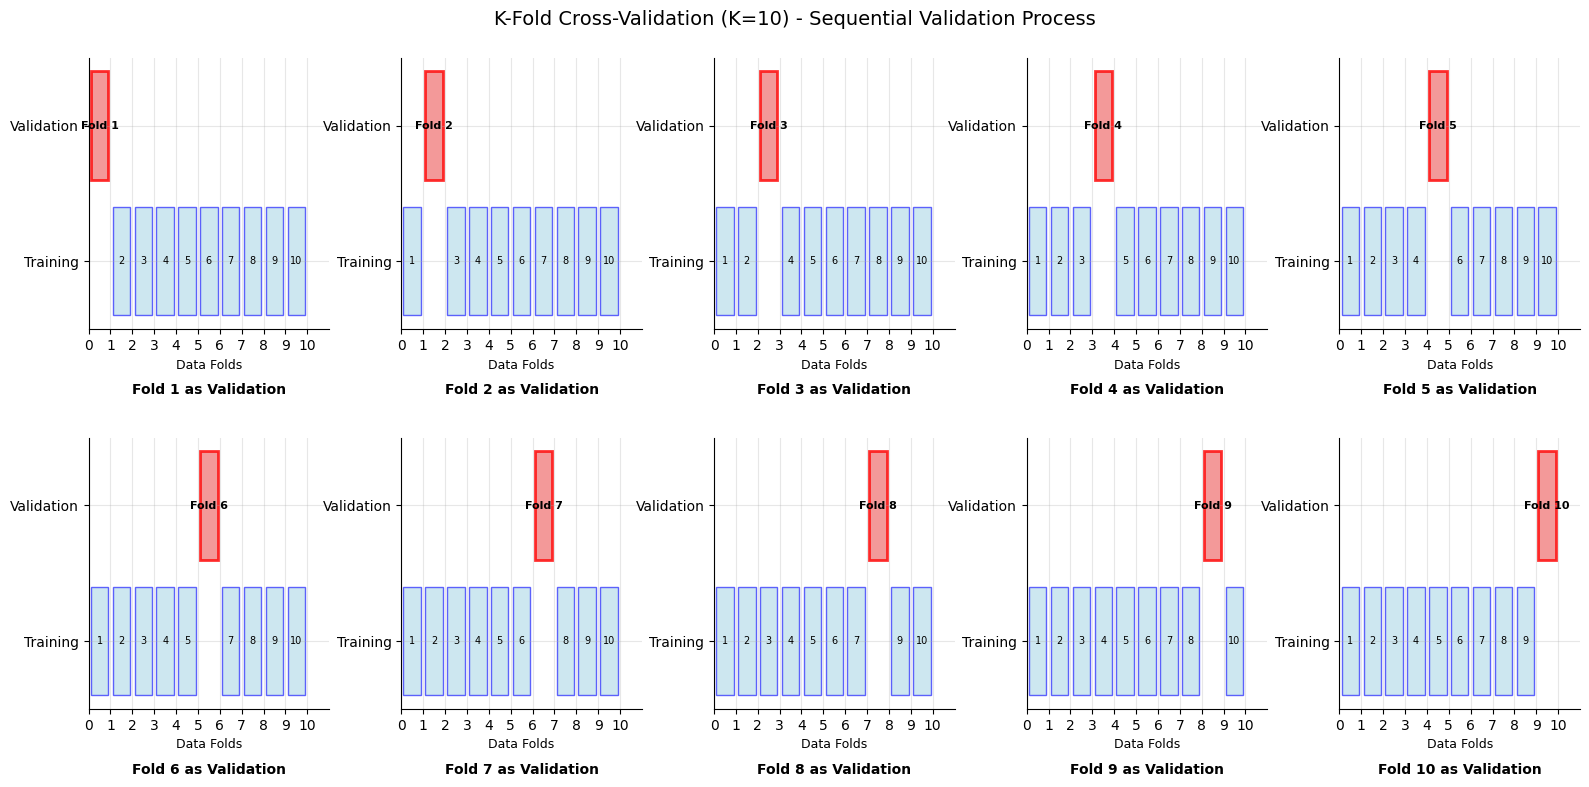

In [2]:
# Create a better visualization of K-Fold CV
fig, axes = plt.subplots(2, 5, figsize=(16, 8))
fig.suptitle(
	"K-Fold Cross-Validation (K=10) - Sequential Validation Process",
	fontsize=14,
	y=0.98,
)

# Flatten axes for easier iteration
axes = axes.flatten()

fold_width = 0.8
n_folds = 10

for fold_idx, ax in enumerate(axes):
	ax.set_xlim(0, 11)
	ax.set_ylim(0, 2)
	ax.set_xticks(range(11))
	ax.set_yticks([0.5, 1.5])
	ax.set_yticklabels(["Training", "Validation"])
	ax.grid(True, alpha=0.3)

	# Draw all folds
	for i in range(n_folds):
		x_start = i + 0.1

		# Determine if this is the validation fold
		if i == fold_idx:
			# Validation fold
			rect = plt.Rectangle(
				(x_start, 1.1),
				fold_width,
				0.8,
				facecolor="lightcoral",
				alpha=0.8,
				edgecolor="red",
				linewidth=2,
			)
			ax.text(
				x_start + fold_width / 2,
				1.5,
				f"Fold {i + 1}",
				ha="center",
				va="center",
				fontsize=8,
				fontweight="bold",
			)
		else:
			# Training fold
			rect = plt.Rectangle(
				(x_start, 0.1),
				fold_width,
				0.8,
				facecolor="lightblue",
				alpha=0.6,
				edgecolor="blue",
				linewidth=1,
			)
			ax.text(
				x_start + fold_width / 2,
				0.5,
				f"{i + 1}",
				ha="center",
				va="center",
				fontsize=7,
			)

		ax.add_patch(rect)

	# Add fold number label
	ax.text(
		5.5,
		-0.4,
		f"Fold {fold_idx + 1} as Validation",
		ha="center",
		va="top",
		fontsize=10,
		fontweight="bold",
	)
	ax.set_xlabel("Data Folds", fontsize=9)

	# Remove top and right spines for cleaner look
	ax.spines["top"].set_visible(False)
	ax.spines["right"].set_visible(False)

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.subplots_adjust(top=0.92, hspace=0.4, wspace=0.3)
plt.show()


This schematic depicts sequential validation, underscoring exhaustive use of data.


### Diagnosing Bias and Variance via Error Comparison
Compare CV error to training error and desired benchmark:

- **High variance (overfitting)**: $\text{CV error} > \text{training error}$. $\hat{f}$ memorises noise; remedy by reducing complexity (e.g., lower $\text{max\_depth}$, higher $\text{min\_samples\_leaf}$), acquiring more data, or ensembling.
- **High bias (underfitting)**: $\text{CV error} \approx \text{training error} > \text{desired error}$. $\hat{f}$ lacks capacity; remedy by increasing complexity (e.g., higher $\text{max\_depth}$, lower $\text{min\_samples\_leaf}$), engineering features, or switching models.

Test error corroborates CV, ideally aligning closely. Learning curves plotting errors against training size or complexity reveal trends: converging high errors signal bias; diverging errors signal variance.

### Implementation in Scikit-Learn
Scikit-learn's `cross_val_score` automates K-Fold CV, returning negative errors for maximisation conventions. Use on training data post initial split.

Self-contained example with the Diabetes dataset (regression on disease progression):

In [3]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.tree import DecisionTreeRegressor

# Load real dataset
data = load_diabetes()
X, y = data.data, data.target

# Set seed for reproducibility
SEED = 123

# Split: 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(
	X, y, test_size=0.3, random_state=SEED
)

# Instantiate regressor
regressor = DecisionTreeRegressor(max_depth=4, min_samples_leaf=0.1, random_state=SEED)

# 10-Fold CV on training set (negative MSE for scoring)
mse_cv_scores = -cross_val_score(
	regressor, X_train, y_train, cv=10, scoring="neg_mean_squared_error", n_jobs=-1
)

# Fit on full training set
regressor.fit(X_train, y_train)

# Predictions
y_pred_train = regressor.predict(X_train)
y_pred_test = regressor.predict(X_test)

# Errors
cv_mse = mse_cv_scores.mean()
train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)

# Display
print(f"CV MSE: {cv_mse:.2f}")
print(f"Train MSE: {train_mse:.2f}")
print(f"Test MSE: {test_mse:.2f}")

CV MSE: 3885.37
Train MSE: 2870.44
Test MSE: 4011.41


Here, CV MSE > Train MSE indicates high variance/overfitting. Test MSE $\approx$ CV MSE validates the diagnosis.


### Validation Curves for Comprehensive Diagnosis
Plot training and CV errors against hyperparameters (e.g., $\text{max\_depth}$) to visualise tradeoff:

In [4]:
from sklearn.model_selection import validation_curve

# Parameter range
param_range = np.arange(1, 11)

# Compute curves
train_scores, cv_scores = validation_curve(
	DecisionTreeRegressor(random_state=SEED),
	X_train,
	y_train,
	param_name="max_depth",
	param_range=param_range,
	cv=10,
	scoring="neg_mean_squared_error",
	n_jobs=-1,
)

# Means
train_mean = -np.mean(train_scores, axis=1)
cv_mean = -np.mean(cv_scores, axis=1)


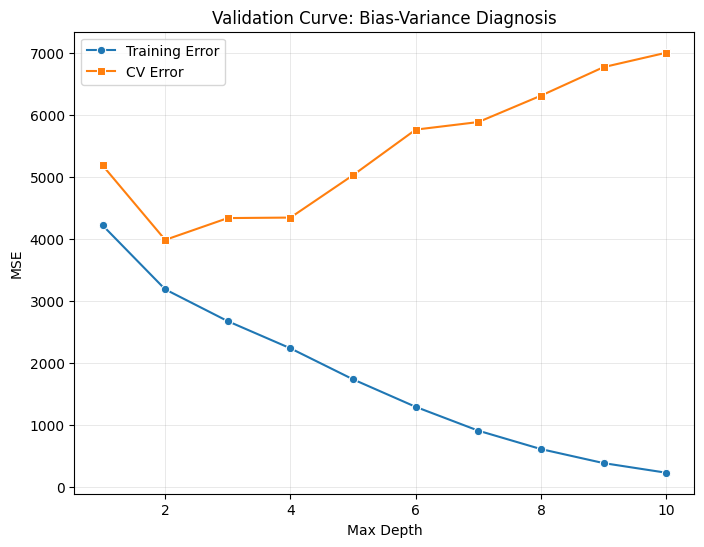

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.lineplot(x=param_range, y=train_mean, label="Training Error", marker="o", ax=ax)
sns.lineplot(x=param_range, y=cv_mean, label="CV Error", marker="s", ax=ax)
ax.set_xlabel("Max Depth")
ax.set_ylabel("MSE")
ax.set_title("Validation Curve: Bias-Variance Diagnosis")
ax.legend()
ax.grid(True, alpha=0.3, linewidth=0.4, color="grey")
plt.show()

Low $\text{max\_depth}$ yields high bias (elevated, converging errors); high yields high variance (diverging errors). Optimal depth minimises CV error.

### Theoretical Rigor and Extensions
K-Fold CV's variance decreases as $O(1/K)$, but finite-sample bias persists for small $K$; $K=5$ or $10$ balances compute and precision. Nested CV tunes hyperparameters unbiasedly: inner for selection, outer for evaluation.

For imbalanced data, repeated stratified K-Fold enhances stability. Theoretically, CV error converges to true generalisation error under i.i.d. assumptions, enabling reliable model selection and diagnosis.